### Introduction
This project analyzes U.S. quarterly GDP growth rates from 2010 to 2023 using data from the U.S. Bureau of Economic Analysis. The dataset, containing twenty data points, represents annual growth rates, with some significant fluctuations during the COVID-19 period, (2020 Q1 to 2021 Q1). Three numerical methods are used to model the economic data: cubic spline interpolation, polynomial fitting, and least squares linear regression. These methods are going to be compared to evaluate their effectiveness in modeling the data, by focusing on accuracy, smoothness, and sensitivity to outliers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define x and y values to reflect the dataset provided. 

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 
             19, 20])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 
             2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# This function sets up the tridiagonal system which is used to compute the 
# second derivatives (or m values). 
def tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * (((y[i+1]-y[i])/ h[i]) - ((y[i]-y[i-1])/ h[i-1]))  
        # Right-hand side vector

    return A, B, C, D
 
#builds tridiagonal system
A, B, C, D = tridiagonal_matrix(x, y)

#thomas algorithm will solve the tridiagonal system
def thomas_algorithm(A, B, C, D):

    n = len(B)
    
    # copies arrays to avoid modifying the original ones
    A = A.copy()
    B = B.copy()
    C = C.copy()
    D = D.copy()
# Forward elimination
    for i in range(1, n):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]
# Back substitution
    middle = np.zeros(n)
    middle[-1] = D[-1] / B[-1]
    for i in range(n-2, -1, -1):
        middle[i] = (D[i] - C[i] * middle[i+1]) / B[i]
    return middle

#solve for interior second derivatives without endpoints
middle = thomas_algorithm(A, B, C, D)
print("Solution:", middle)

#compute m (second derivative)
n = len(x)
M = np.zeros(n)

M[1:-1] = middle   # natural spline (ends = 0)

print("M values:", M)

# evalute spline function evaluates the cubic spline at a given query point
def evaluate_spline(x_data, y_data, M, x_query):

    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    
    #cubic spline interpolation formula
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

# generates smooth x values to help plot the spline
x_vals = np.linspace(min(x), max(x), 200)

#evaluates splines at each x values
y_vals = np.array([
    evaluate_spline(x, y, M, xi)
    for xi in x_vals
    ])

#plotting
plt.figure()
plt.plot(x, y, "o", label="Data Points")      # original points
plt.plot(x_vals, y_vals, label="Cubic Spline")  # smooth curve
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Cubic Spline Interpolation of GDP Growth")
plt.legend()
plt.grid(True)
plt.show()

Solution: [   6.54772205   -3.3908882    -3.78416926   10.12756524  -10.92609171
    1.7768016     6.81888531   -8.05234285    3.19048608    2.49039852
   -2.95208014    5.71792206  -72.71960811  196.36051038 -203.3224334
   80.52922323   -1.19445953   -4.35138512]
M values: [   0.            6.54772205   -3.3908882    -3.78416926   10.12756524
  -10.92609171    1.7768016     6.81888531   -8.05234285    3.19048608
    2.49039852   -2.95208014    5.71792206  -72.71960811  196.36051038
 -203.3224334    80.52922323   -1.19445953   -4.35138512    0.        ]


<Figure size 640x480 with 1 Axes>

### Part A - Cubic Spline Interpolation
   
   For the cubic spline interpolation, piecewise cubic polynomials between each pair of data points were used. Since the dataset consisted of twenty points, the splines required solving for the second derivatives at the interior knots, which resulted in eighteen unknowns. At each interior knot the function itself was continuous, and it remained continuous at the first and second derivatives. The boundary conditions for the natural spline are zero at the endpoints. The 
The resulting system is a tridiagonal linear system, which was solved using Thomas’s algorithm. 

   As can be observed in the figure above, the interpolant is visibly smooth, due to the continuity of the function and its first and second derivatives. One can observe that near the COVID-19 period, extreme values occur, and as a result, the spline curves sharply. The spline is required to pass exactly through all data points, including large outliers, which explains these sharp curves. However, despite the fluctuations, the interpolant remains smooth and reasonable, providing a good representation of the data between points. 
    
The Runge phenomenon refers to oscillations that occur in high-degree polynomial interpolation. This phenomenon, however, is reduced due to the fact that cubic splines in general, and in this case, use low-degree polynomials. The exact interpolation in the cubic spline makes it sensitive to extreme outliers. For example, in the figure above, it can be observed that the COVID-19 period forced the spline to bend. This results in numerical instability but ensures accuracy at known data points. Smoothing splines or weighted least squares would be preferable, as they would allow for some data points to be more relevant than others and produce a more realistic model. 



Polynomial Fit (Degree 4)
MSE: 99.3077379621237
R^2: 0.016632392138784757


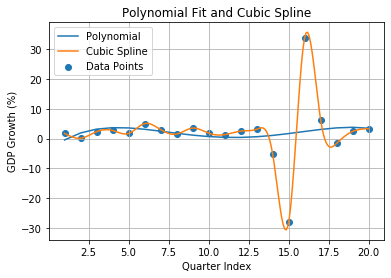

In [3]:
# this function constructs a vandermonde matrix for polynomial fitting
def vandermonde_matrix(x, degree):
    n = len(x)
    #initializes matrix
    V = np.zeros((n, degree+1))
    
    for i in range(n):
        V[i, 0] = 1
        # fills remaining columns with increasing powers of x and
        # uses recursive multiplication
        for j in range(1, degree+1):
            V[i, j] = V[i, j-1] * x[i]
    
    return V
#sets polynomial degree to given degree
degree = 4

#builds vandermonde matrix for the given dataset
V = vandermonde_matrix(x, degree)

#computes square matrix
VT_V = V.T @ V

#computes right hand side vector
VT_y = V.T @ y

#solves linear system
coefficients = np.linalg.solve(VT_V, VT_y)

# computes predicted y-values using the polynomial model
y_pred = V @ coefficients

# mean squared error (avg squared difference between actual and
# predicted y)
mse_poly = np.mean((y - y_pred)**2)
#total sum of squares
ss_total = np.sum((y - np.mean(y))**2)
#residual sum of squares
ss_res = np.sum((y - y_pred)**2)
# r squared
r2_poly = 1 - (ss_res / ss_total)

print("Polynomial Fit (Degree 4)")
print("MSE:", mse_poly)
print("R^2:", r2_poly)

#plotting
plt.figure()
plt.scatter(x, y, label="Data Points")
plt.plot(x, y_pred, label="Polynomial")
plt.plot(x_vals, y_vals, label="Cubic Spline")

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Polynomial Fit and Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()


### Part B - Polynomial & Least Squares Comparison
For part B, a polynomial of degree four was fitted to the data using least squares and plotted.
The polynomial provides a smooth and better captures an approximation of the trend of the data, but it does not pass through every data point. In contrast, the cubic spline interpolates all the data points, and therefore passes through every data point.The cubic spline is an interpolation method, meaning that it was made to pass through every known data point, and as a result, it captures local variations in the data. However, the polynomial is an approximation method and smooths individual fluctuations to instead capture a more accurate general trend. This can be observed in the figure above. The trade-off between approximation and interpolation is that interpolation methods provide exact fits but are sensitive to outliers, while approximation methods provide smoother trends but struggle to capture details.


Least Squares (Excluding COVID Quarters)
Slope: 0.000147058823529468
Intercept: 2.142499999999999
MSE: 2.0837104779411764
R^2: 2.2054826087636314e-07


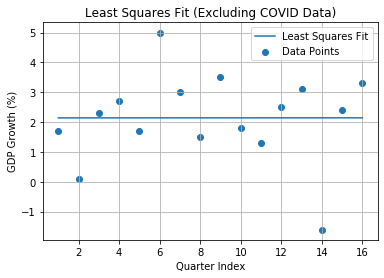

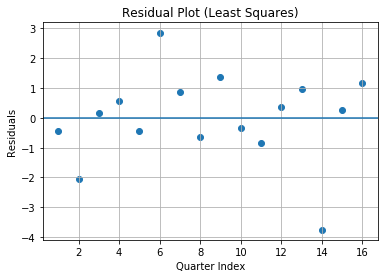

In [4]:
#define dataset excluding the COVID-19 quarters
x_no_covid = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])

y_no_covid = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 
             2.5, 3.1, -1.6, 2.4, 3.3])

# Builds matrix A for linear regression (y = mx+b)
A = np.vstack([x_no_covid, np.ones(len(x_no_covid))]).T

#computes 2x2 system matrix
ATA = A.T @ A
#computes right hand side vector
ATy = A.T @ y_no_covid

#solves for coefficients
coeff = np.linalg.solve(ATA, ATy)

#extracts slope and intercept
m = coeff[0]
b = coeff[1]

print("\nLeast Squares (Excluding COVID Quarters)")
print("Slope:", m)
print("Intercept:", b)

#predicted values from linear model
y_pred = m * x_no_covid + b

# subtracts predicted from actual y values to get residuals
residuals = y_no_covid - y_pred

#mean squared error
mse_ls = np.mean(residuals**2)

#variance in data
ss_total_ls = np.sum((y_no_covid - np.mean(y_no_covid))**2)
#residual variance
ss_res_ls = np.sum(residuals**2)
#r squared
r2_ls = 1 - (ss_res_ls / ss_total_ls)

print("MSE:", mse_ls)
print("R^2:", r2_ls)

#plotting
plt.figure()

plt.scatter(x_no_covid, y_no_covid, label="Data Points")
plt.plot(x_no_covid, y_pred, label="Least Squares Fit")

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Least Squares Fit (Excluding COVID Data)")
plt.legend()
plt.grid(True)

plt.show()

plt.figure()

plt.scatter(x_no_covid, residuals)
plt.axhline(0)

plt.xlabel("Quarter Index")
plt.ylabel("Residuals")
plt.title("Residual Plot (Least Squares)")
plt.grid(True)

plt.show()

### Part B - Polynomial & Least Squares Comparison
When the COVID-19 quarters were removed, a least squares linear model was applied to the data. Residuals were also calculated and plotted. 
As can be observed on the data above, the slope is extremely close to zero, indicating a weak linear trend in GDP growth over the adjusted quarters. The data seems to fluctuate constantly, suggesting that GDP growth does not have a steady increase or decrease over time based on this dataset. Therefore, a linear trend would not make economic sense for this data, since GDP growth is influenced by a myriad of factors that introduce variability, which cannot be captured by a linear relationship. The spread of residuals observed in the second figure above further solidify this statement, suggesting a lack of a clear trend.

### Part C - Method Justification
For a policymaker who needs to estimate GDP growth for a quarter between two known data points, I would recommend cubic spline interpolation. Cubic spline interpolation provides accurate interpolation because it passes through all data points and ensures smoothness through the continuity of its derivatives. Despite its sensitivity to extreme values, the polynomials used by cubic spline interpolation are more stable, and thus provide a better balance between accuracy and smoothness. Polynomial fitting, while better at predicting a general trend, is not accurate enough to estimate intermediate values with the given dataset. 

Big O is a mathematical notation used to describe the time complexity or space complexity of an algorithm as a function of the input size n. It helps evaluate the efficiency of an algorithm by focusing on its growth rate as the input size increases. For this project, cubic spline interpolation, least squares, and polynomial fitting all have linear time complexity, noted as O(n), with respect to the number of data points n. As a result, efficiency does not really affect the choice of method for this case, since the choice was based on accuracy and behavior, and cubic spline interpolation remains the recommended method to use in this scenario.

## Conclusion
This project demonstrated the strengths and limitations of different numerical methods. Cubic spline interpolation performed better at estimating values between data points due to its accuracy and smoothness. Polynomial fitting captured the overall trend but disregarded outliers, and least squares regression failed to represent variability in the data. The results of this project therefore demonstrate that interpolation methods are more ideal for cases where precise estimation between data points is needed, while approximation methods are better suited for cases where the goal is to identify general trends. 


##### OpenAI. (2026). ChatGPT (GPT-5.3) Prompted ChatGPT to debug the code as well as explain concepts regarding interpolation and approximation methods. 